# 7.2

A) Using the sklearn load_boston dataset and use sklearn’s regression class to learn a model.
Use a range of training/test sizes using sklearn’s cross validation package. Run a 100 trials
and graph the mean square error. 

In [109]:
from sklearn.datasets import load_boston
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline



In [110]:
def getErrorwithSize(model, train_sizes, Xtrain, ytrain, Xtest, ytest):
    
    # Initialize needed variables   
    model_mse   = np.zeros(len(train_sizes))  # storing model accuracy
    model_wts   = np.zeros([len(train_sizes), 4]) # storing model weights
    
    #Train our model with increasing data for each iteration
    for size in train_sizes:    
        Xsubtrain = Xtrain[0:size,:]
        ysubtrain = ytrain[0:size]
        model.fit(Xsubtrain, ysubtrain)
    
        # Test our model on fixed test set
        ypredicts = model.predict(Xtest)    
        
        index              = int(size/10)-1   
        model_mse[index]   = np.mean((ypredicts - ytest)**2)
        model_wts[index,:] = np.append(model.intercept_, model.coef_)  

    return model_mse, model_wts

In [111]:
#print(data.shape)
X,y = load_boston(return_X_y=True)
X,y

data = np.c_[X,y]
print(data.shape)
data[0:5,:]
#data = pd.DataFrame(df)
#data = pd.read_csv('data/foodtruck_profits.txt', delimiter=',', header=None).values
#print("Data shape: {}".format(data.shape))
#print('The first few lines of data: {}'.format(data[0:5,:]))

(506, 14)


array([[6.3200e-03, 1.8000e+01, 2.3100e+00, 0.0000e+00, 5.3800e-01,
        6.5750e+00, 6.5200e+01, 4.0900e+00, 1.0000e+00, 2.9600e+02,
        1.5300e+01, 3.9690e+02, 4.9800e+00, 2.4000e+01],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, 0.0000e+00, 4.6900e-01,
        6.4210e+00, 7.8900e+01, 4.9671e+00, 2.0000e+00, 2.4200e+02,
        1.7800e+01, 3.9690e+02, 9.1400e+00, 2.1600e+01],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, 0.0000e+00, 4.6900e-01,
        7.1850e+00, 6.1100e+01, 4.9671e+00, 2.0000e+00, 2.4200e+02,
        1.7800e+01, 3.9283e+02, 4.0300e+00, 3.4700e+01],
       [3.2370e-02, 0.0000e+00, 2.1800e+00, 0.0000e+00, 4.5800e-01,
        6.9980e+00, 4.5800e+01, 6.0622e+00, 3.0000e+00, 2.2200e+02,
        1.8700e+01, 3.9463e+02, 2.9400e+00, 3.3400e+01],
       [6.9050e-02, 0.0000e+00, 2.1800e+00, 0.0000e+00, 4.5800e-01,
        7.1470e+00, 5.4200e+01, 6.0622e+00, 3.0000e+00, 2.2200e+02,
        1.8700e+01, 3.9690e+02, 5.3300e+00, 3.6200e+01]])

In [112]:

#declare model being used
my_model = LinearRegression()


# create a random subsample of training and testing data 

#from sklearn.cross_validation import train_test_split  #no longer functional
from sklearn.model_selection import train_test_split

Dtrain, Dtest = train_test_split(data, test_size=0.3)

In [113]:
print (data.shape)
print (Dtrain.shape)
print (Dtest.shape)

(506, 14)
(354, 14)
(152, 14)


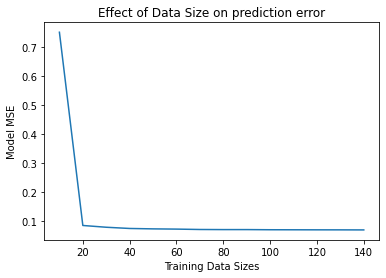

In [114]:
trials = 100

train_sizes = np.arange(10,150,10) # training size from 10 to 70

final_mse       = np.zeros(len(train_sizes))  # storing model prediction error
final_model_wts = np.zeros([len(train_sizes), 4]) # storing model weights

for i in range(0,trials):
    Dtrain, Dtest = train_test_split(data, test_size=0.3)
    Xtrain = Dtrain[:, 0:3]
    ytrain = Dtrain[:,3]

    Xtest = Dtest[:, 0:3]
    ytest = Dtest[:,3]
    
    mse,weights = getErrorwithSize(my_model, train_sizes,Xtrain, ytrain, Xtest, ytest)
    
    final_mse       += mse
    final_model_wts += weights 

final_mse       /= trials
final_model_wts /= trials

#Plot the final MSE
plt.plot(train_sizes, final_mse)

plt.xlabel('Training Data Sizes')
plt.ylabel('Model MSE')
plt.title('Effect of Data Size on prediction error')
plt.show()

B) Load the full iris dataset from last week. Using 10-fold cross validation use sklearn’s
LogisticRegression class to learn a model for each fold. In a Markdown cell report briefly on
what level of accuracy was achieved and how it compared to the results from the decision
tree induction performed last week.

In [148]:
#load Dataset
df = pd.read_csv('data/iris.txt', sep=",", header=None)
df.columns = ['Sepallength', 'Sepalwidth', 'Petallength', 'Petalwidth','Class']
df

,Sepallength,Sepalwidth,Petallength,Petalwidth,Class
0,sepal length,sepal width,petal length,petal width,class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica


In [149]:
df = df.drop([0,0])
df

,Sepallength,Sepalwidth,Petallength,Petalwidth,Class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica


In [150]:
X = df[['Sepallength', 'Sepalwidth', 'Petallength', 'Petalwidth']]
y = df['Class']



In [151]:
#split dataset into 2 parts both training and testing, 70/40 split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.4, random_state=42)

In [181]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1e20)
%time model.fit(X, y)


Wall time: 18 ms


LogisticRegression(C=1e+20)

In [191]:
cv = KFold(n_splits=10, random_state=1, shuffle=True)

In [192]:
scores = cross_val_score(model, Xtrain, ytrain, cv=cv, scoring='accuracy')
print("Accuracy for each fold: {}".format(scores))
print("Mean Accuracy: {}".format(np.mean(scores)))

Accuracy for each fold: [1.         0.88888889 0.88888889 1.         1.         1.
 1.         0.88888889 1.         0.88888889]
Mean Accuracy: 0.9555555555555555


In [193]:
preds = model.predict(X)
# accuracy
(preds == y).mean()


0.9866666666666667

In [156]:
model.intercept_, model.coef_

(array([  4.16734186,  19.23734385, -23.40468571]),
 array([[  8.02085232,  21.04829884, -30.75677785, -14.4619033 ],
        [ -2.77793886,  -7.18335604,  10.66346366,  -1.91284586],
        [ -5.24291346, -13.86494279,  20.09331418,  16.37474916]]))

In a Markdown cell report briefly on what level of accuracy was achieved and how it compared to the results from the decision tree induction performed last week.

with relation to the decision tree induction performed it is clear that our logisticregresion machine learning model far out matched our decision tree classifier machine learning using the 10 fold cross validation, while the similarities are in the way we split our dataset the classification algorithm used in our logistic regression model is far more accurate then the decision tree model used last week in week 6, the decision tree model had a testing accuracy of 80% while the logistic regression algorithm has a 98% testing accuracy, and a mean accuracy after each fold dataset training testing split to have a massive 95% which accounts for its low accuracy returning values for a specific fold within the 10. this being said logitstic regression is far superior then the induction task.

however for the end of the practical solving task, with the same iris dataset the mean accuracy of both stratified kfold and shuffle split within the decision tree classifier proved to be strong and capable however at reaching 90% for stratified kfold and 94% for shuffle split as a mean accuracy over the folds, however, the strongest would still be the logistric regression model which we fitted our data to at a whopping 95% mean average accuracy after all folds.